In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.getcwd())

C:\Users\dhans\Documents\DataScience\Program\NSS_projects\Capstones_Project\notebooks


In [3]:
# Load CDC cancer dataset
cancer_cdc_ml_df = pd.read_csv(
    "../data/BYSITE.TXT",
    sep="|"
)

print(cancer_cdc_ml_df.shape)

(68945, 10)


In [4]:
cancer_cdc_ml_df.head(3)

,YEAR,RACE,SEX,SITE,EVENT_TYPE,AGE_ADJUSTED_CI_LOWER,AGE_ADJUSTED_CI_UPPER,AGE_ADJUSTED_RATE,COUNT,POPULATION
0,1999,All Races,Female,Acute Lymphocytic,Incidence,1.1,1.2,1.2,1652,140394214
1,1999,All Races,Female,Acute Lymphocytic,Mortality,0.4,0.4,0.4,582,142237295
2,2000,All Races,Female,Acute Lymphocytic,Incidence,1.2,1.3,1.3,1788,141865770


In [5]:
# Race Categories
cancer_cdc_ml_df["RACE"].value_counts()

RACE
All Races                                                  11240
Non-Hispanic Black                                          9735
Non-Hispanic American Indian/Alaska Native                  9735
Hispanic of any race                                        9735
Non-Hispanic White                                          9735
Non-Hispanic Asian/Pacific Islander                         9735
American Indian/Alaska Native, Non-Hispanic                 1505
Asian, Non Hispanic                                         1505
Black, Non-Hispanic                                         1505
Hispanic                                                    1505
Native Hawaiinn or other Pacific Islander, Non- Hispani     1505
White, Non-Hispanic                                         1505
Name: count, dtype: int64

In [6]:
# Sex Categories
cancer_cdc_ml_df["SEX"].value_counts()

SEX
Male and Female    24701
Female             22823
Male               21421
Name: count, dtype: int64

In [7]:
# Event Type Categories
cancer_cdc_ml_df["EVENT_TYPE"].value_counts()

EVENT_TYPE
Mortality    35045
Incidence    33900
Name: count, dtype: int64

In [8]:
# Number of Unique Cancer Sites
cancer_cdc_ml_df["SITE"].nunique()

83

In [9]:
# View all cancer site names alphabetically
sorted(cancer_cdc_ml_df["SITE"].unique())

['Acute Lymphocytic',
 'Acute Myeloid',
 'All Cancer Sites Combined',
 'All Sites (comparable to ICD-O-2)',
 'Anus, Anal Canal and Anorectum',
 'Bones and Joints',
 'Brain',
 'Brain and Other Nervous System',
 'Cervix',
 'Chronic Lymphocytic',
 'Chronic Myeloid',
 'Colon and Rectum',
 'Colon excluding Rectum',
 'Corpus',
 'Corpus and Uterus, NOS',
 'Cranial Nerves and Other Nervous System',
 'Digestive System',
 'Endocrine System',
 'Esophagus',
 'Eye and Orbit',
 'Female Breast',
 'Female Breast, <i>in situ</i>',
 'Female Genital System',
 'Floor of Mouth',
 'Gallbladder',
 'Gum and Other Mouth',
 'Hodgkin Lymphoma',
 'Hypopharynx',
 'Kaposi Sarcoma',
 'Kidney and Renal Pelvis',
 'Larynx',
 'Leukemias',
 'Lip',
 'Liver and Intrahepatic Bile Duct',
 'Lung and Bronchus',
 'Lymphomas',
 'Male Breast',
 'Male Genital System',
 'Male and Female Breast',
 'Male and Female Breast, <i>in situ</i>',
 'Melanomas of the Skin',
 'Mesothelioma',
 'Miscellaneous',
 'Myeloma',
 'Nasopharynx',
 'Non-

In [38]:
capstone_cancers = [
    "Female Breast",
    "Prostate",
    "Lung and Bronchus",
    "Colon and Rectum",
    "Pancreas",
    "Liver and Intrahepatic Bile Duct",
    "Melanomas of the Skin",
    "Urinary Bladder",
    "Non-Hodgkin Lymphoma"
]

In [39]:
# Filter CDC data to Capstone cancers

capstone_ml_df = cancer_cdc_ml_df[
    cancer_cdc_ml_df["SITE"].isin(capstone_cancers)
].copy()

print(capstone_ml_df.shape)

(7825, 10)


In [43]:
# Check for missing values

capstone_ml_df.isna().sum()

YEAR                     0
RACE                     0
SEX                      0
SITE                     0
EVENT_TYPE               0
AGE_ADJUSTED_CI_LOWER    0
AGE_ADJUSTED_CI_UPPER    0
AGE_ADJUSTED_RATE        0
COUNT                    0
POPULATION               0
dtype: int64

In [44]:
capstone_ml_df.dtypes

YEAR                     object
RACE                     object
SEX                      object
SITE                     object
EVENT_TYPE               object
AGE_ADJUSTED_CI_LOWER    object
AGE_ADJUSTED_CI_UPPER    object
AGE_ADJUSTED_RATE        object
COUNT                    object
POPULATION                int64
dtype: object

In [45]:
# Inspect AGE_ADJUSTED_RATE values

capstone_ml_df["AGE_ADJUSTED_RATE"].sample(20, random_state=321)

21671    51.8
61359    44.9
22776    20.0
43037     5.4
58557    20.9
42843     0.4
43056    16.5
65363    71.7
62097     8.6
9347      5.0
34698    19.4
18656     7.3
18774     4.5
32890    13.3
5028      8.5
54681    56.2
23433    22.8
58177    34.8
4201     48.3
36164    63.8
Name: AGE_ADJUSTED_RATE, dtype: object

In [46]:
# Convert AGE_ADJUSTED_RATE to numeric

capstone_ml_df["AGE_ADJUSTED_RATE"] = pd.to_numeric(capstone_ml_df["AGE_ADJUSTED_RATE"], errors="coerce")

In [47]:
# Check current data types

capstone_ml_df.dtypes

YEAR                      object
RACE                      object
SEX                       object
SITE                      object
EVENT_TYPE                object
AGE_ADJUSTED_CI_LOWER     object
AGE_ADJUSTED_CI_UPPER     object
AGE_ADJUSTED_RATE        float64
COUNT                     object
POPULATION                 int64
dtype: object

In [48]:
capstone_ml_df["YEAR"] = pd.to_numeric(
    capstone_ml_df["YEAR"],
    errors="coerce"
)

capstone_ml_df["AGE_ADJUSTED_CI_LOWER"] = pd.to_numeric(
    capstone_ml_df["AGE_ADJUSTED_CI_LOWER"],
    errors="coerce"
)

capstone_ml_df["AGE_ADJUSTED_CI_UPPER"] = pd.to_numeric(
    capstone_ml_df["AGE_ADJUSTED_CI_UPPER"],
    errors="coerce"
)

capstone_ml_df["COUNT"] = pd.to_numeric(
    capstone_ml_df["COUNT"],
    errors="coerce"
)

In [49]:
capstone_ml_df.dtypes

YEAR                     float64
RACE                      object
SEX                       object
SITE                      object
EVENT_TYPE                object
AGE_ADJUSTED_CI_LOWER    float64
AGE_ADJUSTED_CI_UPPER    float64
AGE_ADJUSTED_RATE        float64
COUNT                    float64
POPULATION                 int64
dtype: object

In [51]:
# Check for missing values after conversion

capstone_ml_df[
    ["YEAR",
     "AGE_ADJUSTED_CI_LOWER",
     "AGE_ADJUSTED_CI_UPPER",
     "AGE_ADJUSTED_RATE",
     "COUNT"]
].isna().sum()

YEAR                     325
AGE_ADJUSTED_CI_LOWER    141
AGE_ADJUSTED_CI_UPPER    141
AGE_ADJUSTED_RATE        141
COUNT                    141
dtype: int64

In [52]:
# Percent of rows with missing AGE_ADJUSTED_RATE

capstone_ml_df["AGE_ADJUSTED_RATE"].isna().mean() * 100

np.float64(1.8019169329073481)

In [53]:
# Check missing values in Female Breast rows

cancer_cdc_ml_df[
    cancer_cdc_ml_df["SITE"] == "Female Breast"
].isna().sum()

YEAR                     0
RACE                     0
SEX                      0
SITE                     0
EVENT_TYPE               0
AGE_ADJUSTED_CI_LOWER    0
AGE_ADJUSTED_CI_UPPER    0
AGE_ADJUSTED_RATE        0
COUNT                    0
POPULATION               0
dtype: int64

In [54]:
# Remove rows with missing values

capstone_ml_df = capstone_ml_df.dropna()

In [56]:
# Verify shape

capstone_ml_df.shape

(7362, 10)

In [57]:
# Incidence vs Mortality counts

capstone_ml_df["EVENT_TYPE"].value_counts()

EVENT_TYPE
Mortality    3762
Incidence    3600
Name: count, dtype: int64

In [58]:
# Cancer type counts

capstone_ml_df["SITE"].value_counts()

SITE
Colon and Rectum                    900
Lung and Bronchus                   900
Pancreas                            900
Liver and Intrahepatic Bile Duct    898
Non-Hodgkin Lymphoma                890
Urinary Bladder                     861
Melanomas of the Skin               813
Female Breast                       600
Prostate                            600
Name: count, dtype: int64

In [59]:
# Summary statistics for numeric columns

capstone_ml_df.describe()

,YEAR,AGE_ADJUSTED_CI_LOWER,AGE_ADJUSTED_CI_UPPER,AGE_ADJUSTED_RATE,COUNT,POPULATION
count,7362.000000,7362.000000,7362.000000,7362.000000,7362.000000,7.362000e+03
mean,2010.915376,25.139527,27.061396,26.064358,19218.198180,6.578568e+07
std,7.116019,33.701969,34.613692,34.139875,40729.636653,8.006938e+07
min,1999.000000,0.100000,0.300000,0.200000,16.000000,2.943770e+05
25%,2005.000000,6.200000,7.600000,6.900000,564.000000,9.507203e+06
50%,2011.000000,12.700000,14.400000,13.500000,2953.000000,2.354206e+07
75%,2017.000000,28.650000,30.675000,29.600000,17249.000000,1.011907e+08
max,2023.000000,265.000000,271.700000,268.300000,282273.000000,3.349149e+08


In [60]:
# Distribution of age-adjusted rates

capstone_ml_df["AGE_ADJUSTED_RATE"].describe()

count    7362.000000
mean       26.064358
std        34.139875
min         0.200000
25%         6.900000
50%        13.500000
75%        29.600000
max       268.300000
Name: AGE_ADJUSTED_RATE, dtype: float64

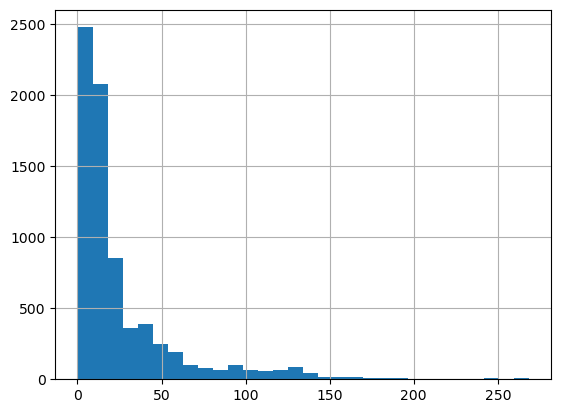

In [61]:
# Histogram of age-adjusted rates

capstone_ml_df["AGE_ADJUSTED_RATE"].hist(bins=30)
plt.show()

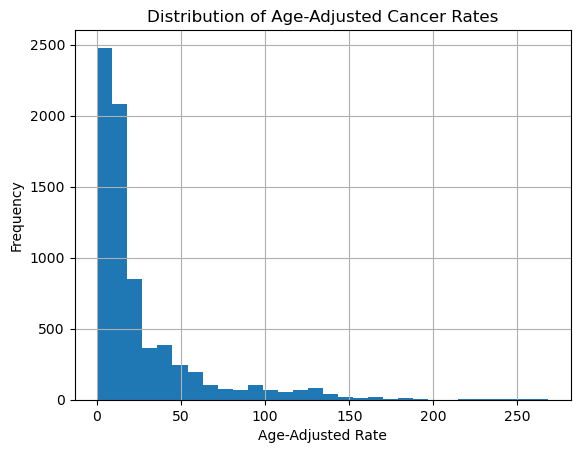

In [62]:
# Histogram of AGE_ADJUSTED_RATE

capstone_ml_df["AGE_ADJUSTED_RATE"].hist(bins=30)

plt.title("Distribution of Age-Adjusted Cancer Rates")
plt.xlabel("Age-Adjusted Rate")
plt.ylabel("Frequency")

plt.show()

In [63]:
# Average burden metrics by cancer type

cancer_summary = (
    capstone_ml_df
    .groupby("SITE")
    .agg(
        avg_rate=("AGE_ADJUSTED_RATE", "mean"),
        avg_count=("COUNT", "mean"),
        avg_population=("POPULATION", "mean")
    )
)

cancer_summary

,avg_rate,avg_count,avg_population
SITE,,,
Colon and Rectum,28.788000,21525.844444,6.729248e+07
Female Breast,64.470333,43547.983333,5.120941e+07
Liver and Intrahepatic Bile Duct,9.061915,5214.197105,6.744169e+07
Lung and Bronchus,46.121778,39601.708889,6.729248e+07
Melanomas of the Skin,6.266175,9137.607626,7.430582e+07
Non-Hodgkin Lymphoma,10.891124,9358.137079,6.804508e+07
Pancreas,11.064000,8866.613333,6.729248e+07
Prostate,74.326333,39470.843333,4.972930e+07
Urinary Bladder,9.647271,9568.365854,7.029951e+07
